14b7e46b8bb0257f1e8b54eb4bc146c1545c4bb3

In [12]:
import wandb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
api = wandb.Api()
keys = ['_step', 'losses.error', 'Train Epoch NLL']

In [16]:
# run 1
run1 = api.run("thelikhit-unistuttgart/thesis/bg9t9k3c")
run2 = api.run("thelikhit-unistuttgart/thesis/k4ylq8ry")

df_run1 = pd.DataFrame(run1.history(keys=keys, samples=100000))
df_run2 = pd.DataFrame(run2.history(keys=keys, samples=100000))

wandb: WARNING Unable to load pandas, call history with pandas=False
wandb: WARNING Unable to load pandas, call history with pandas=False


In [18]:
# Adjust steps of run 2 to continue from run 1
last_step_run1 = df_run1['_step'].max()
df_run2['_step'] = df_run2['_step'] + last_step_run1

# Combine dataframes
combined_df = pd.concat([df_run1, df_run2], ignore_index=True)

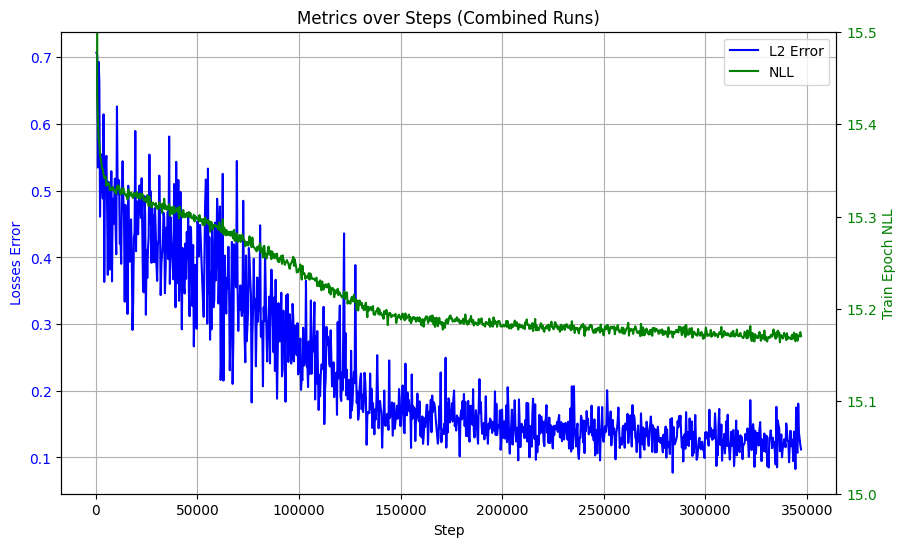

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plotting on the primary y-axis (ax1)
ax1.plot(combined_df['_step'], combined_df['losses.error'], label='L2 Error', color='blue')
ax1.set_xlabel('Step')
ax1.set_ylabel('Losses Error', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True)

# Creating a secondary y-axis (ax2)
ax2 = ax1.twinx()
ax2.plot(combined_df['_step'], combined_df['Train Epoch NLL'], label='NLL', color='green')
ax2.set_ylabel('Train Epoch NLL', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.set_ylim(top=15.5, bottom=15)

# Add legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.title('Training Loss')
plt.show()